# CIE-552 Computer Vision — Term Project
## Part 3 — Experiment 1: Color Space Comparison (RGB vs HSV vs Grayscale)

**Objective:** Determine whether the input color space significantly affects classification performance on the IIITDMJ_Smoke dataset, using the same custom CNN architecture from Part 2 as a controlled baseline.

**Hypothesis:** Because smoke and fog are atmospheric phenomena with distinct spectral signatures, color representation will significantly impact model performance. HSV may outperform RGB by separating chromatic (hue) from luminance (value) information more explicitly.

**Controlled variables (kept identical across all runs):**
- CNN architecture (3-block custom CNN from Part 2)
- Training hyperparameters (Adam lr=0.001, 30 epochs, batch size 32)
- Train/val/test split
- Random seed (42)

**Independent variable:** Input color space — RGB, HSV, Grayscale

**Dependent variable:** Test accuracy, per-class F1, validation loss curve

## 1. Setup & Imports

In [ ]:
!pip install tensorflow scikit-image scikit-learn opencv-python-headless matplotlib seaborn --quiet

In [13]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from pathlib import Path
from skimage.io import imread
from skimage.color import rgb2hsv, rgb2gray
from skimage.transform import resize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

#  Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# Shared constants (from Part 1 & 2)
IMG_SIZE     = (128, 128)
CLASS_NAMES  = ['smoke', 'non_smoke', 'fog_smoke', 'fog_non_smoke']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = 4
BATCH_SIZE   = 32
EPOCHS       = 20
PALETTE      = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

print(f'TensorFlow : {tf.__version__}')
print('All imports OK')

TensorFlow : 2.20.0
All imports OK


## 2. Mount Drive & Extract Dataset

In [10]:
from google.colab import drive
import zipfile

drive.mount('/content/drive', force_remount=True)

ZIP_PATH    = Path('/content/drive/MyDrive/IIITDMJ_Smoke.zip')
EXTRACT_DIR = Path('/content/IIITDMJ_Smoke')

if not EXTRACT_DIR.exists():
    print('Extracting ZIP...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Done')
else:
    print('Already extracted, skipping')

DATASET_ROOT = Path('/content/IIITDMJ_Smoke/IIITDMJ_Smoke')
print('Dataset root:', DATASET_ROOT)

Mounted at /content/drive
Extracting ZIP...
Done
Dataset root: /content/IIITDMJ_Smoke/IIITDMJ_Smoke


## 3. Color Space Conversion

Each function loads an image and returns it converted to the target color space.

- **RGB**: No conversion.
- **HSV**: Hue, Saturation  Value .  using skimage's `rgb2hsv` to convert the imagesd .
- **Grayscale**: Single  channel computed as a weighted sum of RGB: `0.299R + 0.587G + 0.114B`.  shaped to `(H, W, 1)` so the model input shape is consistent.

In [11]:
def load_rgb(img_path):
    """Load image as RGB float32 [0,1], shape (H,W,3)."""
    # Ensure img_path is a string, even if it comes as bytes
    if isinstance(img_path, bytes):
        img_path = img_path.decode('utf-8')
    img = imread(img_path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[2] == 4:
        img = img[:, :, :3]
    img = resize(img, IMG_SIZE, anti_aliasing=True, mode='reflect')
    return img.astype(np.float32)

def load_hsv(img_path):
    """Load image and convert to HSV float32 [0,1], shape (H,W,3)."""
    img = load_rgb(img_path)               # get normalised RGB first
    return rgb2hsv(img).astype(np.float32) # skimage outputs [0,1] directly

def load_grayscale(img_path):
    """Load image and convert to grayscale float32 [0,1], shape (H,W,1)."""
    img  = load_rgb(img_path)
    gray = rgb2gray(img)                   # shape (H,W)
    return gray[:, :, np.newaxis].astype(np.float32)  # → (H,W,1)


LOADERS = {
    'RGB':       load_rgb,
    'HSV':       load_hsv,
    'Grayscale': load_grayscale,
}

print('Color space loaders defined: RGB, HSV, Grayscale')

Color space loaders defined: RGB, HSV, Grayscale


## 4. Visualise the Three Color Spaces

Before training, visualise what the same image looks like in each color space. This makes the paper figure for the Methodology section.

Train: 18,914  Val: 2,363  Test: 2,367


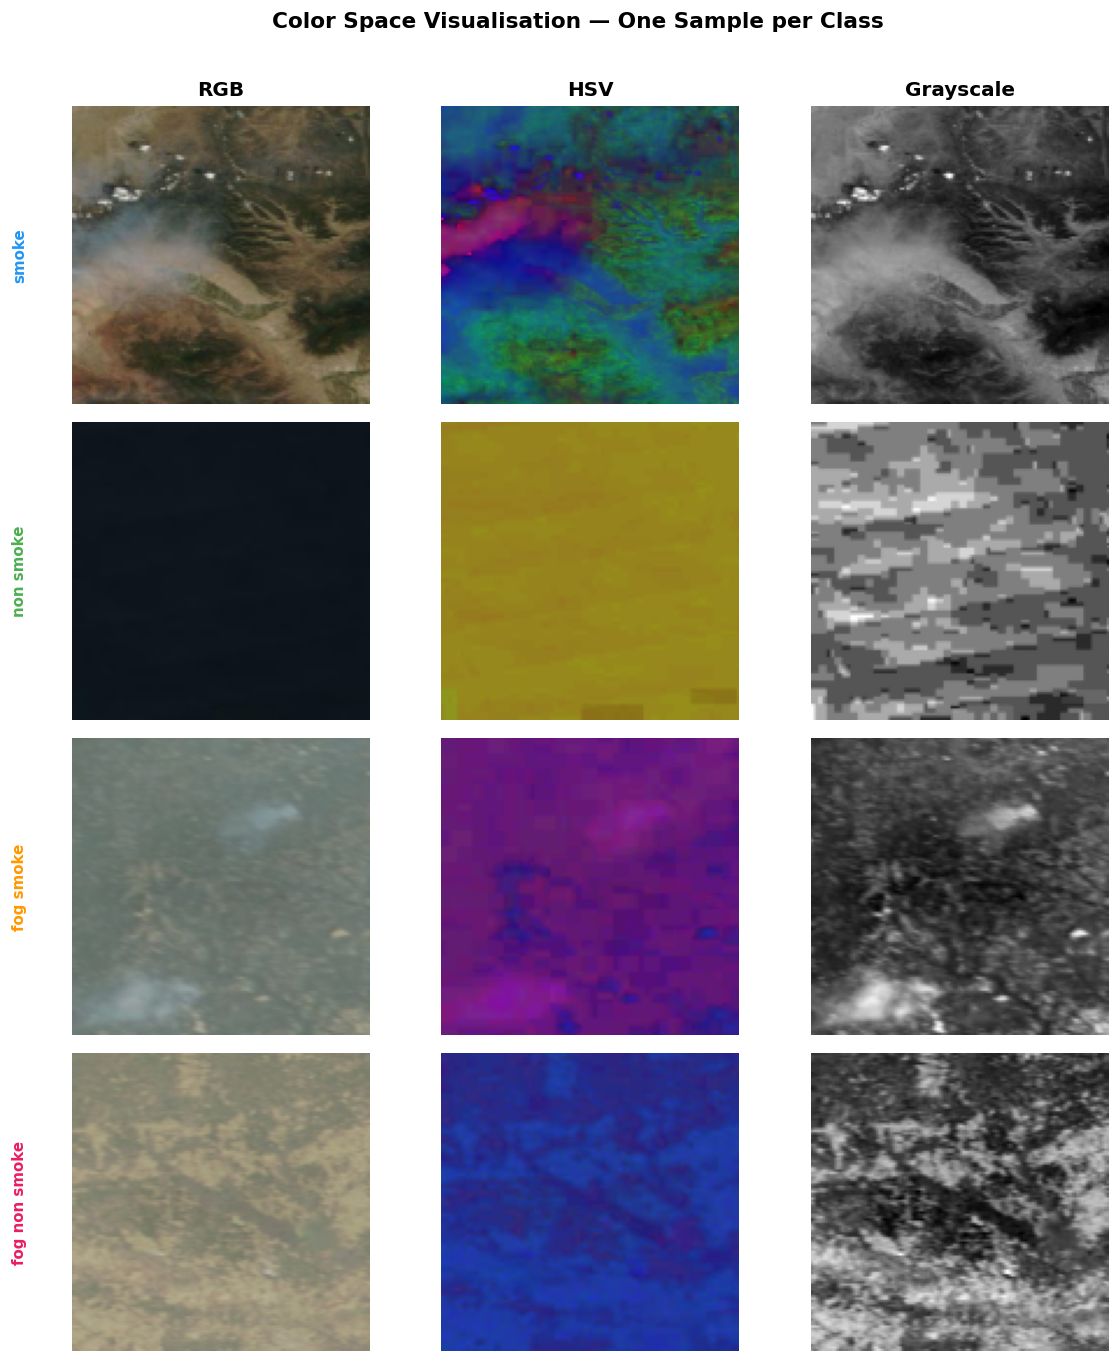

Saved: colorspace_visualisation.png


In [14]:


def load_split_paths(root, split):
    records = []
    for class_name in CLASS_NAMES:
        class_dir = root / split / class_name
        if not class_dir.exists():
            continue
        for p in list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')):
            records.append({'path': str(p), 'label': CLASS_LABELS[class_name],
                            'class_name': class_name})
    return pd.DataFrame(records)


df_train = load_split_paths(DATASET_ROOT, 'train')
df_val   = load_split_paths(DATASET_ROOT, 'val')
df_test  = load_split_paths(DATASET_ROOT, 'test')

print(f'Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}')

# Visualisation: one sample per class × three color spaces
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(10, NUM_CLASSES * 2.8))
cs_titles = ['RGB', 'HSV', 'Grayscale']

for row, class_name in enumerate(CLASS_NAMES):
    sample_path = df_train[df_train['class_name'] == class_name].sample(
        1, random_state=SEED)['path'].values[0]

    imgs = [
        load_rgb(sample_path),
        load_hsv(sample_path),
        load_grayscale(sample_path)[:, :, 0],
    ]
    cmaps = [None, None, 'gray']

    for col, (img, title, cmap) in enumerate(zip(imgs, cs_titles, cmaps)):
        axes[row, col].imshow(img, cmap=cmap)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(title, fontsize=12, fontweight='bold')
        if col == 0:
            axes[row, col].text(-0.15, 0.5, class_name.replace('_', ' '),
                                 fontsize=9, fontweight='bold',
                                 color=PALETTE[row],
                                 transform=axes[row, col].transAxes,
                                 va='center', ha='right', rotation=90)

plt.suptitle('Color Space Visualisation — One Sample per Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('colorspace_visualisation.png', bbox_inches='tight')
plt.show()
print('Saved: colorspace_visualisation.png')

## 5. Build tf.data Pipelines for Each Color Space

We build a custom `tf.data` pipeline using `from_tensor_slices` + `map` so we can apply our Python conversion functions. This avoids loading all images into RAM at once.

In [7]:
def make_tf_dataset(df, loader_fn, shuffle=False):

    paths  = df['path'].values
    labels = df['label'].values

    def load_and_convert(path, label):
        img = tf.numpy_function(
            func=loader_fn,
            inp=[path],
            Tout=tf.float32
        )
        label_onehot = tf.one_hot(label, NUM_CLASSES)
        return img, label_onehot

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_and_convert, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


def make_test_dataset(df, loader_fn):
    paths  = df['path'].values
    labels = df['label'].values

    def load_and_convert(path, label):
        img = tf.numpy_function(func=loader_fn, inp=[path], Tout=tf.float32)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_convert, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


print('tf.data pipeline factory functions defined.')

tf.data pipeline factory functions defined.


## 6. CNN Architecture

Identical to Part 2's custom CNN. The only difference is input_channels.  3 for RGB/HSV, 1 for Grayscale.

In [ ]:
def build_cnn(input_channels=3, num_classes=NUM_CLASSES):

    input_shape = (*IMG_SIZE, input_channels)

    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name=f'CNN_{input_channels}ch')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Quick sanity check — print summary for RGB version
build_cnn(input_channels=3).summary()
print('\nGrayscale variant (1 channel):')
build_cnn(input_channels=1).summary()

Model: "CNN_3ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,036 (32.36 MB)

 Trainable params: 8,483,588 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "CNN_1ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,460 (32.36 MB)

 Trainable params: 8,483,012 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 7. Training

trianing only for hsv and greyscale since rgb was trained in part 2, we'll use the results form there

In [ ]:
EXPERIMENTS = {
    'HSV':       (load_hsv,       3),
    'Grayscale': (load_grayscale, 1),
}

all_results   = {}
all_histories = {}

for cs_name, (loader_fn, n_channels) in EXPERIMENTS.items():
    print('\n' + '='*60)
    print(f'  Training on: {cs_name}  ({n_channels} channel(s))')
    print('='*60)

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    train_ds = make_tf_dataset(df_train, loader_fn, shuffle=True).cache()
    val_ds   = make_tf_dataset(df_val,   loader_fn, shuffle=False).cache()
    test_ds  = make_test_dataset(df_test, loader_fn).cache()

    model = build_cnn(input_channels=n_channels)

    def fix_shape(x, y, channels=n_channels):
        x.set_shape([None, *IMG_SIZE, channels])
        y.set_shape([None, NUM_CLASSES])
        return x, y

    def fix_test_shape(x, y, channels=n_channels):
        x.set_shape([None, *IMG_SIZE, channels])
        return x, y

    train_ds = train_ds.map(fix_shape)
    val_ds   = val_ds.map(fix_shape)
    test_ds  = test_ds.map(fix_test_shape)

    ckpt_path = f'best_{cs_name.lower()}.h5'
    cb_list = [
        callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-6, verbose=0),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=cb_list,
        verbose=1
    )
    all_histories[cs_name] = history

    model.load_weights(ckpt_path)

    y_pred_list, y_true_list = [], []
    for x_batch, y_batch in test_ds:
        probs = model.predict(x_batch, verbose=0)
        y_pred_list.extend(np.argmax(probs, axis=1))
        y_true_list.extend(y_batch.numpy())

    y_pred = np.array(y_pred_list)
    y_true = np.array(y_true_list)

    acc    = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES, output_dict=True)

    all_results[cs_name] = {
        'accuracy': acc,
        'y_true':   y_true,
        'y_pred':   y_pred,
        'report':   report,
        'history':  history,
    }

    print(f'\n[{cs_name}] Test Accuracy: {acc*100:.2f}%')
    print(classification_report(y_true, y_pred,
                                 target_names=[c.replace('_',' ') for c in CLASS_NAMES]))

print('\n HSV and Grayscale experiments complete.')


  Training on: HSV  (3 channel(s))
Epoch 1/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.6485 - loss: 3.0275

592/592 ━━━━━━━━━━━━━━━━━━━━ 403s 656ms/step - accuracy: 0.6911 - loss: 1.1907 - val_accuracy: 0.7245 - val_loss: 0.5867 - learning_rate: 0.0010
Epoch 2/20
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7166 - loss: 0.6427

592/592 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.7356 - loss: 0.6002 - val_accuracy: 0.7876 - val_loss: 0.5102 - learning_rate: 0.0010
Epoch 3/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7871 - loss: 0.5280 - val_accuracy: 0.7711 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 4/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7670 - loss: 0.5903

592/592 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.7872 - loss: 0.5491 - val_accuracy: 0.8168 - val_loss: 0.4322 - learning_rate: 0.0010
Epoch 5/20
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8025 - loss: 0.5310

592/592 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.8126 - loss: 0.5097 - val_accuracy: 0.8172 - val_loss: 0.5665 - learning_rate: 0.0010
Epoch 6/20
589/592 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8076 - loss: 0.5179

...

592/592 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.6091 - loss: 0.8085 - val_accuracy: 0.6399 - val_loss: 1.2582 - learning_rate: 0.0010
Epoch 7/20
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6401 - loss: 0.7750

592/592 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.6490 - loss: 0.7559 - val_accuracy: 0.7275 - val_loss: 0.6289 - learning_rate: 0.0010
Epoch 8/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.6690 - loss: 0.7217 - val_accuracy: 0.6289 - val_loss: 0.9837 - learning_rate: 0.0010
Epoch 9/20
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6756 - loss: 0.7072

592/592 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.6823 - loss: 0.6909 - val_accuracy: 0.7706 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 10/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.6867 - loss: 0.6852 - val_accuracy: 0.7355 - val_loss: 0.5947 - learning_rate: 0.0010
Epoch 11/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6945 - loss: 0.7014 - val_accuracy: 0.7478 - val_loss: 0.6048 - learning_rate: 0.0010
Epoch 12/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.6957 - loss: 0.6849 - val_accuracy: 0.7634 - val_loss: 0.6068 - learning_rate: 0.0010
Epoch 13/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7000 - loss: 0.6688 - val_accuracy: 0.7545 - val_loss: 0.5904 - learning_rate: 0.0010
Epoch 14/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7085 - loss: 0.6588 - val_accuracy: 0.7596 - val_loss: 0.6158 - learning_rate: 0.0010
Epoch 15/20
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7286 - loss: 0

592/592 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.7287 - loss: 0.6026 - val_accuracy: 0.7893 - val_loss: 0.4767 - learning_rate: 5.0000e-04
Epoch 16/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7280 - loss: 0.6022

592/592 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.7304 - loss: 0.5891 - val_accuracy: 0.8096 - val_loss: 0.4504 - learning_rate: 5.0000e-04
Epoch 17/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.7394 - loss: 0.5680 - val_accuracy: 0.8053 - val_loss: 0.4642 - learning_rate: 5.0000e-04
Epoch 18/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.7416 - loss: 0.5604 - val_accuracy: 0.7964 - val_loss: 0.4594 - learning_rate: 5.0000e-04
Epoch 19/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7426 - loss: 0.5656 - val_accuracy: 0.7854 - val_loss: 0.5167 - learning_rate: 5.0000e-04
Epoch 20/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7518 - loss: 0.5502 - val_accuracy: 0.7719 - val_loss: 0.5600 - learning_rate: 5.0000e-04

[Grayscale] Test Accuracy: 81.50%
               precision    recall  f1-score   support

        smoke       0.72      0.96      0.82       479
    non smoke       0.92      0.72      0.81       682
    fog smoke   

## 8. Confusion Matrix

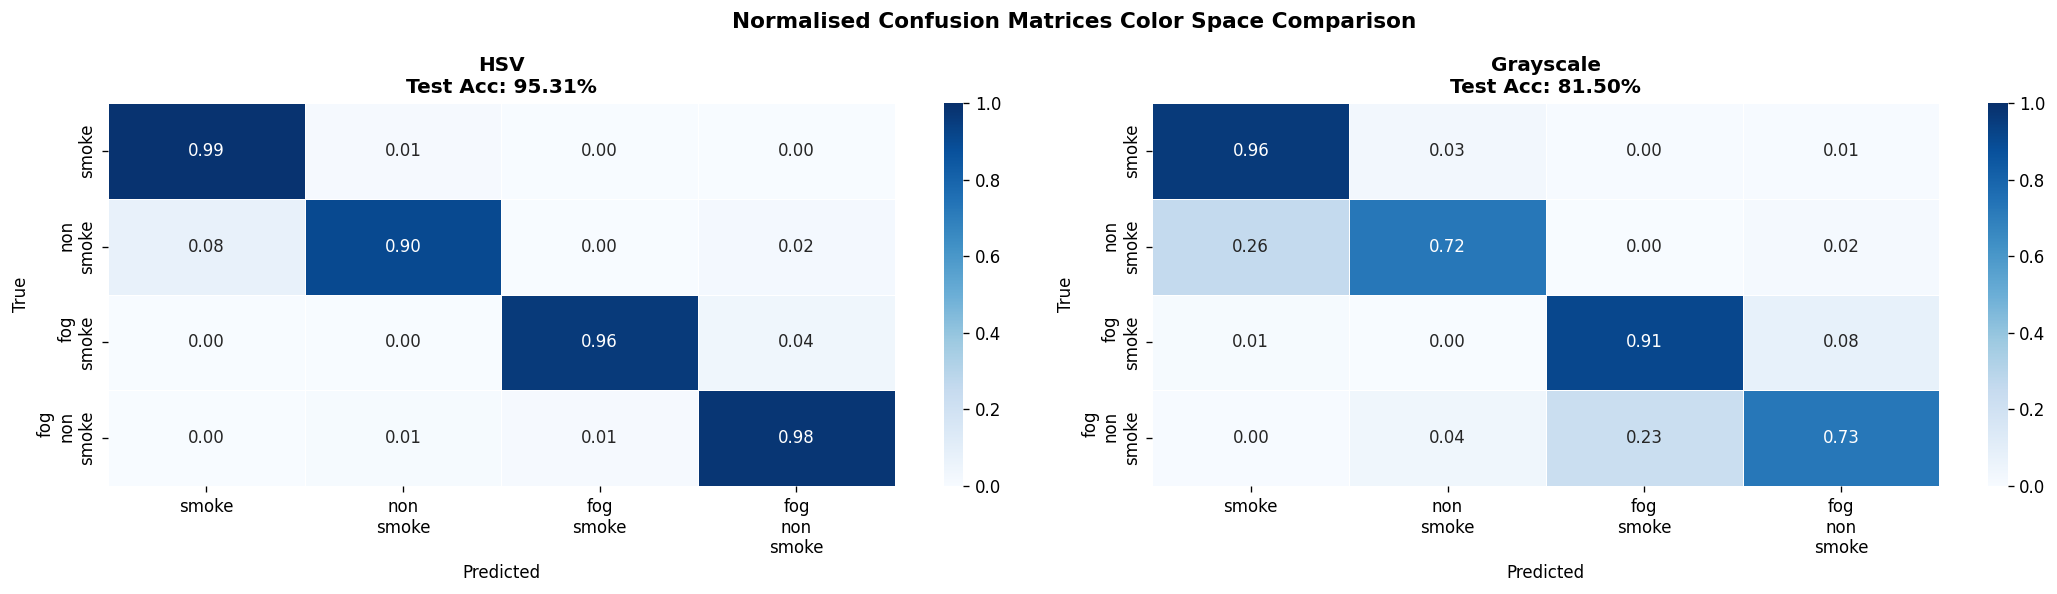

Saved: colorspace_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
labels = [c.replace('_', '\n') for c in CLASS_NAMES]

for ax, (cs_name, res) in zip(axes, all_results.items()):
    cm_norm = confusion_matrix(res['y_true'], res['y_pred']).astype(float)
    cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    ax.set_title(f'{cs_name}\nTest Acc: {res["accuracy"]*100:.2f}%',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices Color Space Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('colorspace_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: colorspace_confusion_matrices.png')

## 9. Summary Comparison Table


 Color Space Comparison
 Color Space  Input Channels Test Accuracy (%) smoke F1 non_smoke F1 fog_smoke F1 fog_non_smoke F1 Macro F1
RGB (Part 2)               3             96.92    0.976        0.965        0.976            0.962    0.970
         HSV               3             95.31    0.941        0.940        0.970            0.962    0.953
   Grayscale               1             81.50    0.820        0.811        0.827            0.802    0.815


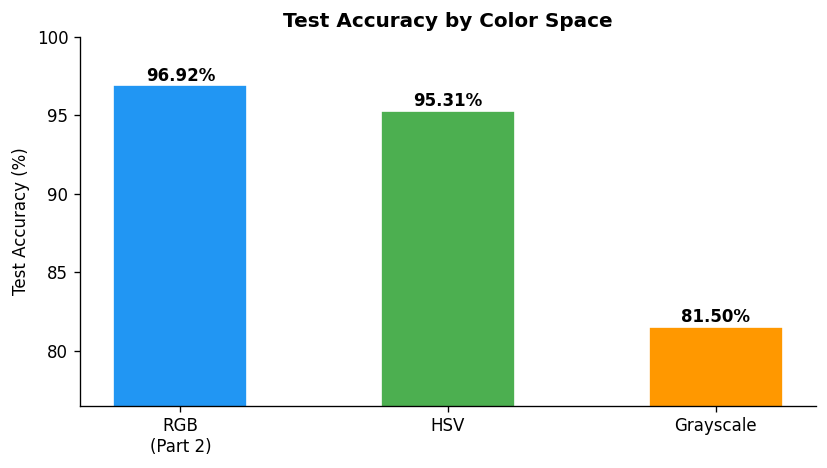

Saved: colorspace_accuracy_bar.png


In [ ]:
CS_COLORS = {'RGB': '#2196F3', 'HSV': '#4CAF50', 'Grayscale': '#FF9800'}

# Add RGB from Part 2 into results for comparison
RGB_TEST_ACC = 0.9692
rgb_row = {
    'Color Space': 'RGB (Part 2)', 'Input Channels': 3,
    'Test Accuracy (%)': f'{RGB_TEST_ACC*100:.2f}',
    'smoke F1': '0.976', 'non_smoke F1': '0.965',
    'fog_smoke F1': '0.976', 'fog_non_smoke F1': '0.962',
    'Macro F1': '0.970',
}

rows = [rgb_row]
for cs_name, res in all_results.items():
    r = res['report']
    rows.append({
        'Color Space':       cs_name,
        'Input Channels':    3 if cs_name != 'Grayscale' else 1,
        'Test Accuracy (%)': f"{res['accuracy']*100:.2f}",
        'smoke F1':          f"{r['smoke']['f1-score']:.3f}",
        'non_smoke F1':      f"{r['non_smoke']['f1-score']:.3f}",
        'fog_smoke F1':      f"{r['fog_smoke']['f1-score']:.3f}",
        'fog_non_smoke F1':  f"{r['fog_non_smoke']['f1-score']:.3f}",
        'Macro F1':          f"{r['macro avg']['f1-score']:.3f}",
    })

summary_df = pd.DataFrame(rows)
print('\n Color Space Comparison')
print(summary_df.to_string(index=False))

accs      = [RGB_TEST_ACC * 100] + [all_results[cs]['accuracy'] * 100 for cs in EXPERIMENTS]
cs_labels = ['RGB\n(Part 2)'] + list(EXPERIMENTS.keys())
bar_colors = [CS_COLORS['RGB']] + [CS_COLORS[cs] for cs in EXPERIMENTS]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cs_labels, accs, color=bar_colors, edgecolor='white', width=0.5)
ax.set_ylim(min(accs) - 5, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy by Color Space', fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('colorspace_accuracy_bar.png', bbox_inches='tight')
plt.show()
print('Saved: colorspace_accuracy_bar.png')

In [ ]:
# Clear RAM
import gc
import tensorflow as tf

for var in ['model', 'model_hsv', 'model_gray', 'X_train', 'X_val', 'X_test',
            'y_train', 'y_val', 'y_test', 'y_train_oh', 'y_val_oh',
            'train_ds', 'val_ds', 'test_ds', 'history', 'history_hsv', 'history_gray']:
    if var in dir():
        del var

# Clear Keras session
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

print('RAM cleared. Ready for Transfer Learning.')

RAM cleared. Ready for Transfer Learning.


## 11. Experiment 2 — Transfer Learning with MobileNetV2

We use MobileNetV2 pretrained on ImageNet as a feature extractor, then fine-tune the top layers.
Training has two phases:
- **Phase 1 (Feature Extraction):** MobileNetV2 base is frozen, only the new classifier head is trained for 10 epochs.
- **Phase 2 (Fine-tuning):** The top 30 layers of the base are unfrozen and trained at a lower learning rate for 10 more epochs.

Baseline for comparison: Part 2 custom CNN — 96.92% test accuracy.

In [ ]:
train_ds_tl = make_tf_dataset(df_train, load_rgb, shuffle=True)
val_ds_tl   = make_tf_dataset(df_val,   load_rgb, shuffle=False)
test_ds_tl  = make_test_dataset(df_test, load_rgb)

def fix_shape_rgb(x, y):
    x.set_shape([None, *IMG_SIZE, 3])
    y.set_shape([None, NUM_CLASSES])
    return x, y

def fix_test_shape_rgb(x, y):
    x.set_shape([None, *IMG_SIZE, 3])
    return x, y

train_ds_tl = train_ds_tl.map(fix_shape_rgb)
val_ds_tl   = val_ds_tl.map(fix_shape_rgb)
test_ds_tl  = test_ds_tl.map(fix_test_shape_rgb)

print('Transfer learning datasets ready.')

Transfer learning datasets ready.


In [ ]:
def build_mobilenet(num_classes=NUM_CLASSES):
    # Load MobileNetV2 without the top classifier,
    base_model = keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  #freezing base layers

    model = keras.Sequential([
        layers.Rescaling(scale=2., offset=-1.),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name='MobileNetV2_Transfer')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model


random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
model_tl, base_model = build_mobilenet()
model_tl.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Cell: Phase 1 — Feature Extraction

In [ ]:
print('Phase 1: Feature Extraction')

history_phase1 = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[
        callbacks.ModelCheckpoint('best_mobilenet_phase1.h5',
                                   monitor='val_accuracy',
                                   save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=3, min_lr=1e-6, verbose=0),
    ],
    verbose=1
)

print(f'\n Phase 1 best val accuracy: '
      f'{max(history_phase1.history["val_accuracy"])*100:.2f}%')

Phase 1: Feature Extraction
Epoch 1/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.7514 - loss: 0.6266

592/592 ━━━━━━━━━━━━━━━━━━━━ 384s 611ms/step - accuracy: 0.8298 - loss: 0.4306 - val_accuracy: 0.8798 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 2/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8967 - loss: 0.2662

592/592 ━━━━━━━━━━━━━━━━━━━━ 353s 591ms/step - accuracy: 0.8998 - loss: 0.2570 - val_accuracy: 0.9103 - val_loss: 0.2369 - learning_rate: 0.0010
Epoch 3/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 318s 537ms/step - accuracy: 0.9172 - loss: 0.2097 - val_accuracy: 0.9056 - val_loss: 0.2332 - learning_rate: 0.0010
Epoch 4/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9254 - loss: 0.1888

592/592 ━━━━━━━━━━━━━━━━━━━━ 307s 518ms/step - accuracy: 0.9275 - loss: 0.1839 - val_accuracy: 0.9200 - val_loss: 0.1959 - learning_rate: 0.0010
Epoch 5/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9321 - loss: 0.1707

592/592 ━━━━━━━━━━━━━━━━━━━━ 328s 555ms/step - accuracy: 0.9361 - loss: 0.1605 - val_accuracy: 0.9259 - val_loss: 0.1794 - learning_rate: 0.0010
Epoch 6/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9478 - loss: 0.1356

592/592 ━━━━━━━━━━━━━━━━━━━━ 346s 585ms/step - accuracy: 0.9449 - loss: 0.1407 - val_accuracy: 0.9285 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 7/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9528 - loss: 0.1200

592/592 ━━━━━━━━━━━━━━━━━━━━ 331s 558ms/step - accuracy: 0.9490 - loss: 0.1261 - val_accuracy: 0.9344 - val_loss: 0.1851 - learning_rate: 0.0010
Epoch 8/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9565 - loss: 0.1076

592/592 ━━━━━━━━━━━━━━━━━━━━ 369s 536ms/step - accuracy: 0.9564 - loss: 0.1107 - val_accuracy: 0.9386 - val_loss: 0.1652 - learning_rate: 0.0010
Epoch 9/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 341s 568ms/step - accuracy: 0.9584 - loss: 0.1019 - val_accuracy: 0.9331 - val_loss: 0.1789 - learning_rate: 0.0010
Epoch 10/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 363s 537ms/step - accuracy: 0.9621 - loss: 0.0936 - val_accuracy: 0.9331 - val_loss: 0.1660 - learning_rate: 0.0010

 Phase 1 best val accuracy: 93.86%


##Fine Tuning

In [ ]:
print('Phase 2: Fine-tuning (top 20 layers unfrozen)')

# Unfreeze the top 20 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

#recompile but wiht lower learning rate (we don't want to meess up the trianed weights)
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[
        callbacks.ModelCheckpoint('best_mobilenet_phase2.h5',
                                   monitor='val_accuracy',
                                   save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=3, min_lr=1e-7, verbose=0),
    ],
    verbose=1
)

print(f'\n Phase 2 best val accuracy: '
      f'{max(history_phase2.history["val_accuracy"])*100:.2f}%')

Phase 2: Fine-tuning (top 20 layers unfrozen)
Epoch 1/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7345 - loss: 0.6462

592/592 ━━━━━━━━━━━━━━━━━━━━ 344s 535ms/step - accuracy: 0.8327 - loss: 0.4169 - val_accuracy: 0.8345 - val_loss: 0.4640 - learning_rate: 1.0000e-04
Epoch 2/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9321 - loss: 0.1757

592/592 ━━━━━━━━━━━━━━━━━━━━ 341s 497ms/step - accuracy: 0.9359 - loss: 0.1662 - val_accuracy: 0.8743 - val_loss: 0.3374 - learning_rate: 1.0000e-04
Epoch 3/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9578 - loss: 0.1112

592/592 ━━━━━━━━━━━━━━━━━━━━ 302s 463ms/step - accuracy: 0.9574 - loss: 0.1097 - val_accuracy: 0.8777 - val_loss: 0.3586 - learning_rate: 1.0000e-04
Epoch 4/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9701 - loss: 0.0807

592/592 ━━━━━━━━━━━━━━━━━━━━ 328s 473ms/step - accuracy: 0.9702 - loss: 0.0793 - val_accuracy: 0.9340 - val_loss: 0.1988 - learning_rate: 1.0000e-04
Epoch 5/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 369s 552ms/step - accuracy: 0.9735 - loss: 0.0670 - val_accuracy: 0.9171 - val_loss: 0.2484 - learning_rate: 1.0000e-04
Epoch 6/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9708 - loss: 0.0771

592/592 ━━━━━━━━━━━━━━━━━━━━ 304s 514ms/step - accuracy: 0.9750 - loss: 0.0648 - val_accuracy: 0.9551 - val_loss: 0.1285 - learning_rate: 1.0000e-04
Epoch 7/10
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9812 - loss: 0.0479

592/592 ━━━━━━━━━━━━━━━━━━━━ 313s 499ms/step - accuracy: 0.9803 - loss: 0.0502 - val_accuracy: 0.9606 - val_loss: 0.1162 - learning_rate: 1.0000e-04
Epoch 8/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 286s 483ms/step - accuracy: 0.9813 - loss: 0.0471 - val_accuracy: 0.9314 - val_loss: 0.2277 - learning_rate: 1.0000e-04
Epoch 9/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 275s 464ms/step - accuracy: 0.9828 - loss: 0.0466 - val_accuracy: 0.8726 - val_loss: 0.4445 - learning_rate: 1.0000e-04
Epoch 10/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 331s 479ms/step - accuracy: 0.9852 - loss: 0.0404 - val_accuracy: 0.9530 - val_loss: 0.1348 - learning_rate: 1.0000e-04

 Phase 2 best val accuracy: 96.06%


##Evaluating the model

MobileNetV2 Test Accuracy: 95.35%
Custom CNN  Test Accuracy: 96.92%  (Part 2 baseline)
Improvement: -1.57pp

               precision    recall  f1-score   support

        smoke       0.97      0.98      0.97       479
    non smoke       0.94      0.95      0.94       682
    fog smoke       0.96      0.97      0.97       536
fog non smoke       0.95      0.93      0.94       670

     accuracy                           0.95      2367
    macro avg       0.96      0.96      0.96      2367
 weighted avg       0.95      0.95      0.95      2367



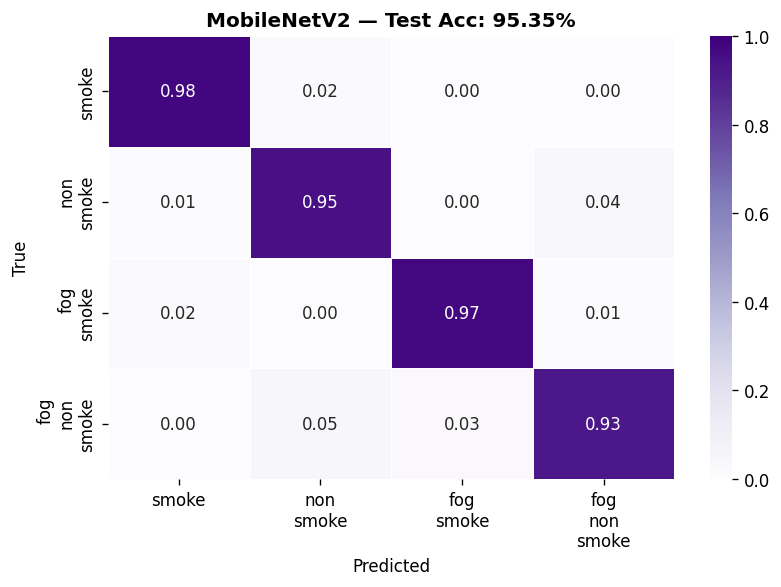

In [ ]:
model_tl.load_weights('best_mobilenet_phase2.h5')

y_pred_list, y_true_list = [], []
for x_batch, y_batch in test_ds_tl:
    probs = model_tl.predict(x_batch, verbose=0)
    y_pred_list.extend(np.argmax(probs, axis=1))
    y_true_list.extend(y_batch.numpy())

y_pred_tl = np.array(y_pred_list)
y_true_tl = np.array(y_true_list)

tl_acc    = accuracy_score(y_true_tl, y_pred_tl)
tl_report = classification_report(y_true_tl, y_pred_tl,
                                    target_names=CLASS_NAMES, output_dict=True)

print(f'MobileNetV2 Test Accuracy: {tl_acc*100:.2f}%')
print(f'Custom CNN  Test Accuracy: 96.92%  (Part 2 baseline)')
print(f'Improvement: {(tl_acc - 0.9692)*100:+.2f}pp\n')
print(classification_report(y_true_tl, y_pred_tl,
                              target_names=[c.replace('_',' ') for c in CLASS_NAMES]))


# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true_tl, y_pred_tl).astype(float)
cm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples', ax=ax,
            xticklabels=[c.replace('_','\n') for c in CLASS_NAMES],
            yticklabels=[c.replace('_','\n') for c in CLASS_NAMES],
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
ax.set_title(f'MobileNetV2 — Test Acc: {tl_acc*100:.2f}%', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('mobilenet_confusion_matrix.png', bbox_inches='tight')
plt.show()



## 13. Experiment 3  Robustness Under Synthetic Gaussian Noise

We evaluate how the trained models will act with
with Gaussian noise at three intensity levels.

**Noise levels:**
- σ = 0.05 (Mild) — represents light sensor noise in a CCTV camera at dusk
- σ = 0.10 (Moderate) — represents a low-quality camera or heavy compression artifacts
- σ = 0.20 (Severe) — represents a heavily degraded feed, e.g. a camera in rain or fog with sensor interference

**Models tested:**
- Custom CNN baseline (Part 2) — best_model saved as `cnn_baseline_best.h5`


**Baseline for comparison:**  test accuracy CNN: 96.92%, MobileNetV2: 95.35%

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import gc
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  Load both saved models
DRIVE_OUT = Path('/content/drive/MyDrive')

model_cnn = keras.models.load_model(DRIVE_OUT / 'cnn_baseline_best.h5')

print('CNN loaded      :', model_cnn.input_shape)

print('\nLoading clean test set...')

test_ds_clean = make_test_dataset(df_test, load_rgb)

X_test_clean_list = []
y_test_list = []
for images, labels in test_ds_clean:
    X_test_clean_list.append(images.numpy())
    y_test_list.append(labels.numpy())

X_test_clean = np.concatenate(X_test_clean_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

print(f'Test set: {X_test_clean.shape}  labels: {y_test.shape}')

y_pred_check = np.argmax(model_cnn.predict(X_test_clean, verbose=0), axis=1)
print(f'\nCNN clean accuracy check: {accuracy_score(y_test, y_pred_check)*100:.2f}%')
print('(Should match 96.92% from Part 2)')

CNN loaded      : (None, 128, 128, 3)

Loading clean test set...
Test set: (2367, 128, 128, 3)  labels: (2367,)

CNN clean accuracy check: 96.70%
(Should match 96.92% from Part 2)


## Gaussian noise function

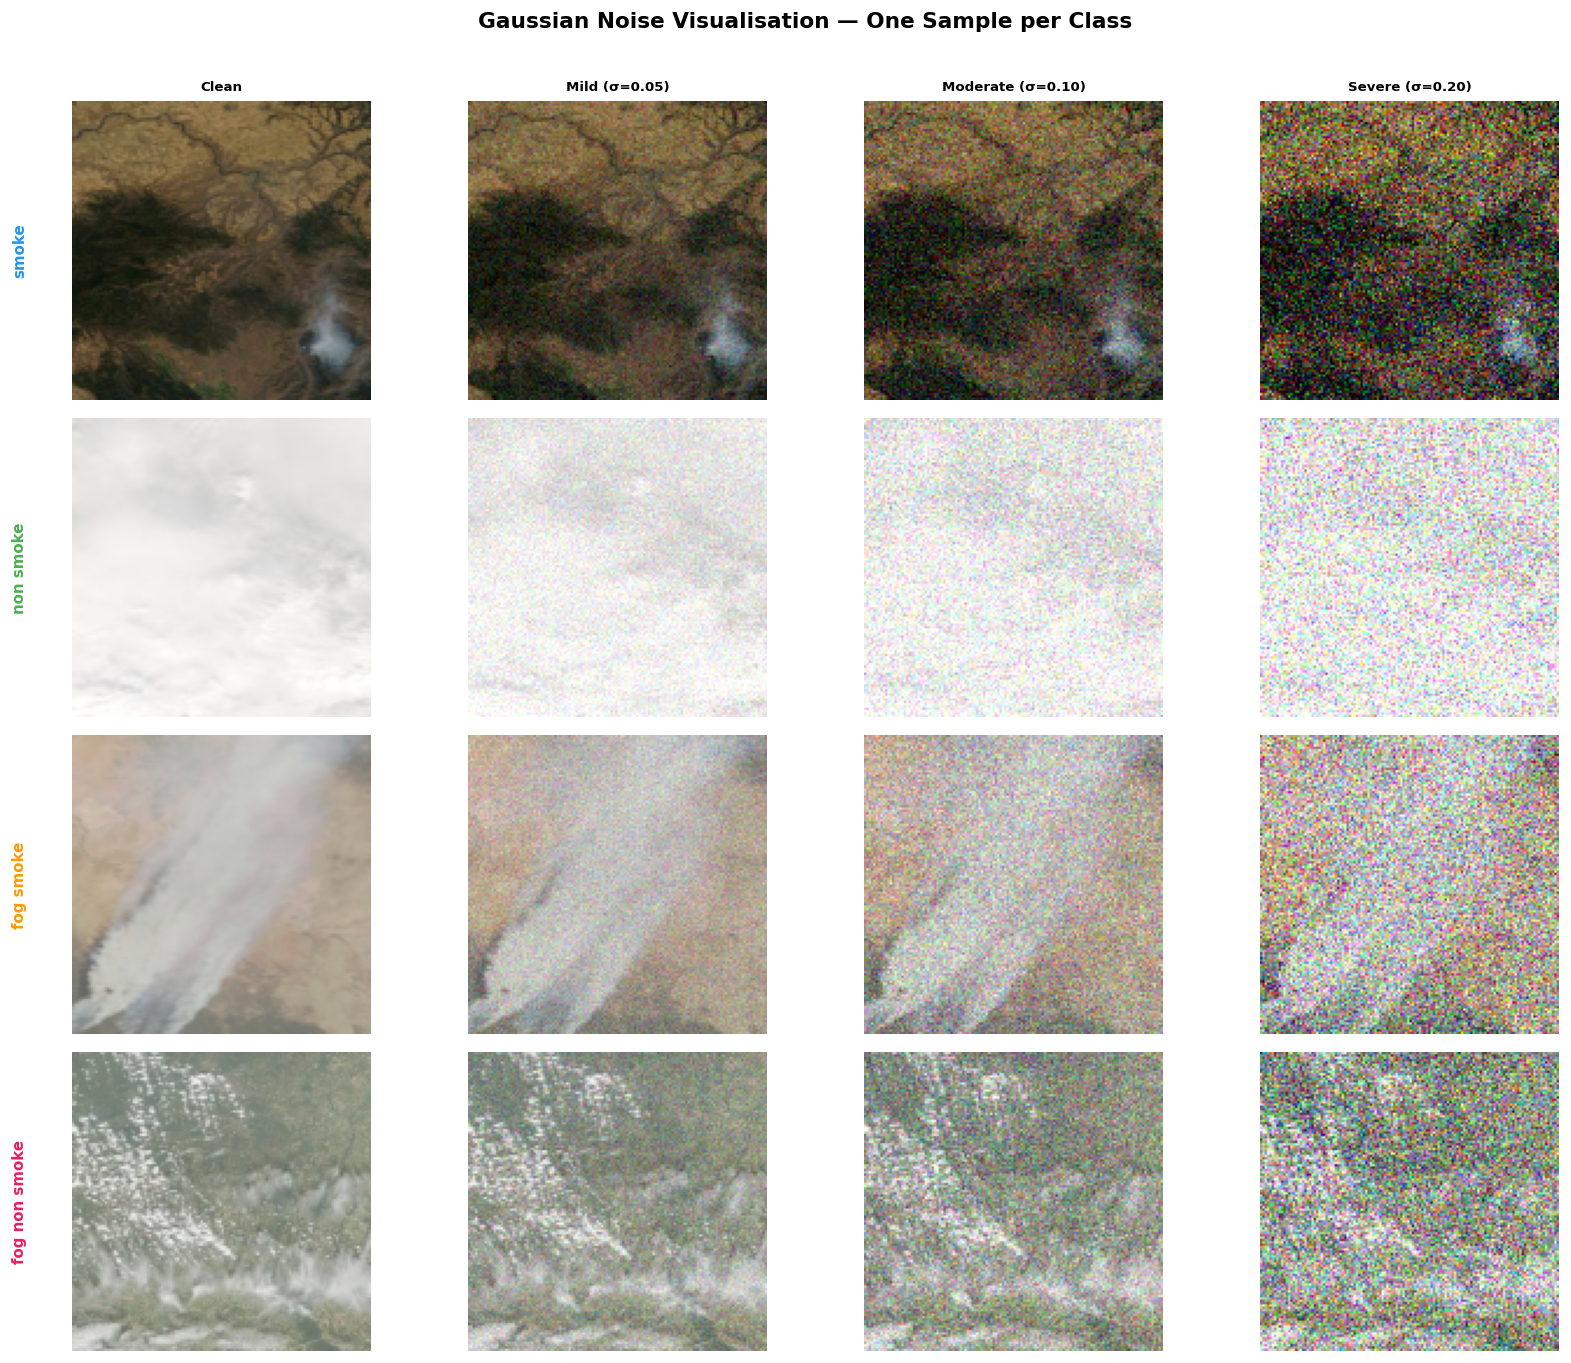

Saved: noise_visualisation.png


In [16]:
NOISE_LEVELS = {
    'Mild (σ=0.05)':     0.05,   # light sensor noise, CCTV at dusk
    'Moderate (σ=0.10)': 0.10,   # low-quality camera or compression artifacts
    'Severe (σ=0.20)':   0.20,   # degraded feed, camera in rain/fog
}
NOISE_COLORS = {
    'Mild (σ=0.05)':     '#4CAF50',
    'Moderate (σ=0.10)': '#FF9800',
    'Severe (σ=0.20)':   '#E91E63',
}

def add_gaussian_noise(X, sigma):

    noise = np.random.normal(loc=0.0, scale=sigma, size=X.shape).astype(np.float32)
    return np.clip(X + noise, 0.0, 1.0)


np.random.seed(42)

fig, axes = plt.subplots(NUM_CLASSES, len(NOISE_LEVELS) + 1,
                          figsize=(14, NUM_CLASSES * 2.8))
col_titles = ['Clean'] + list(NOISE_LEVELS.keys())

for row, class_name in enumerate(CLASS_NAMES):
    class_idx = np.where(y_test == CLASS_LABELS[class_name])[0][0]
    clean_img  = X_test_clean[class_idx]

    imgs = [clean_img] + [
        add_gaussian_noise(clean_img[np.newaxis], sigma)[0]
        for sigma in NOISE_LEVELS.values()
    ]

    for col, (img, title) in enumerate(zip(imgs, col_titles)):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(title, fontsize=8, fontweight='bold')
        if col == 0:
            axes[row, col].text(
                -0.15, 0.5, class_name.replace('_', ' '),
                fontsize=9, fontweight='bold', color=PALETTE[row],
                transform=axes[row, col].transAxes,
                va='center', ha='right', rotation=90)

plt.suptitle('Gaussian Noise Visualisation — One Sample per Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('noise_visualisation.png', bbox_inches='tight')
plt.show()
print('Saved: noise_visualisation.png')

In [17]:
np.random.seed(42)

results_noise = {'CNN': {}}

for model_name, model in [('CNN', model_cnn)]:
    y_pred = np.argmax(model.predict(X_test_clean, verbose=0), axis=1)
    results_noise[model_name]['Clean'] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'report':   classification_report(y_test, y_pred,
                        target_names=CLASS_NAMES, output_dict=True),
        'y_pred':   y_pred,
        'sigma':    0.0,
    }

for noise_label, sigma in NOISE_LEVELS.items():
    print(f'\nApplying {noise_label}...')
    X_noisy = add_gaussian_noise(X_test_clean, sigma)

    for model_name, model in [('CNN', model_cnn)]:
        y_pred = np.argmax(model.predict(X_noisy, verbose=0), axis=1)
        acc    = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred,
                     target_names=CLASS_NAMES, output_dict=True)

        results_noise[model_name][noise_label] = {
            'accuracy': acc,
            'report':   report,
            'y_pred':   y_pred,
            'sigma':    sigma,
        }
        print(f'  {model_name:12s} — Accuracy: {acc*100:.2f}%  '
              f'Macro F1: {report["macro avg"]["f1-score"]:.3f}')

    # Free noisy array
    del X_noisy
    gc.collect()

print('\nAll noise evaluations complete.')


Applying Mild (σ=0.05)...
  CNN          — Accuracy: 71.57%  Macro F1: 0.710

Applying Moderate (σ=0.10)...
  CNN          — Accuracy: 49.35%  Macro F1: 0.414

Applying Severe (σ=0.20)...
  CNN          — Accuracy: 42.04%  Macro F1: 0.296

All noise evaluations complete.


In [18]:
all_labels = ['Clean'] + list(NOISE_LEVELS.keys())

rows = []
for model_name in ['CNN']:
    for label in all_labels:
        r   = results_noise[model_name][label]
        rep = r['report']
        rows.append({
            'Model':             model_name,
            'Noise Level':       label,
            'sigma':             r['sigma'],
            'Test Accuracy (%)': f"{r['accuracy']*100:.2f}",
            'Delta Acc':         f"{(r['accuracy'] - results_noise[model_name]['Clean']['accuracy'])*100:+.2f}",
            'Macro F1':          f"{rep['macro avg']['f1-score']:.3f}",
        })

summary_df = pd.DataFrame(rows)
print('\n Gaussian Noise Robustness Summary ')
print(summary_df.to_string(index=False))


 Gaussian Noise Robustness Summary 
Model       Noise Level  sigma Test Accuracy (%) Delta Acc Macro F1
  CNN             Clean   0.00             96.70     +0.00    0.968
  CNN     Mild (σ=0.05)   0.05             71.57    -25.14    0.710
  CNN Moderate (σ=0.10)   0.10             49.35    -47.36    0.414
  CNN   Severe (σ=0.20)   0.20             42.04    -54.67    0.296


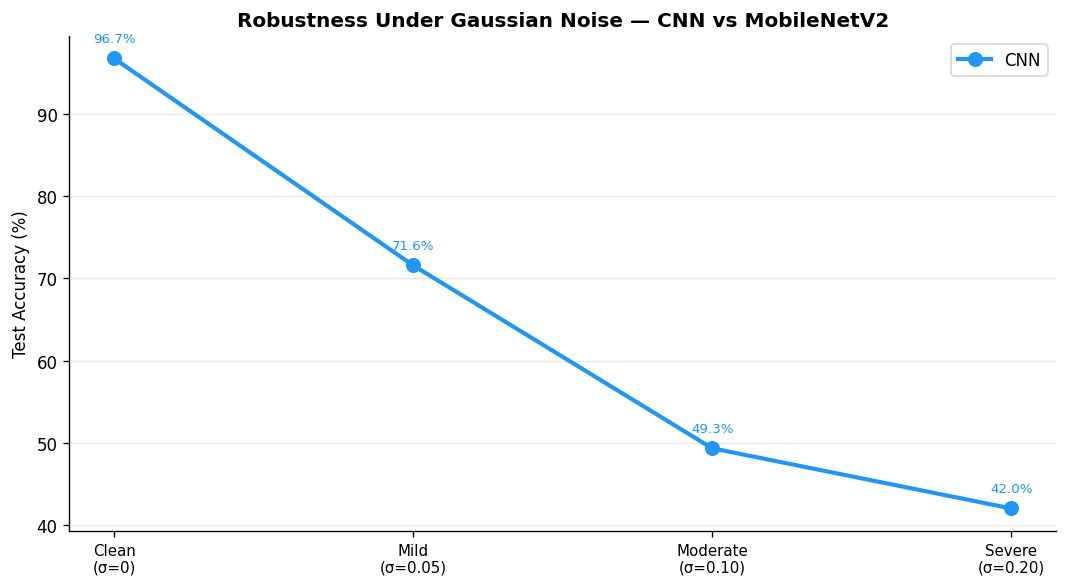

Saved: noise_accuracy_comparison.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

line_styles = {'CNN': 'o-'}
model_colors = {'CNN': '#2196F3'}

x_labels = ['Clean'] + list(NOISE_LEVELS.keys())
x_pos    = range(len(x_labels))

for model_name in ['CNN']:
    accs = [results_noise[model_name][lbl]['accuracy'] * 100
            for lbl in x_labels]
    ax.plot(x_pos, accs,
            line_styles[model_name],
            color=model_colors[model_name],
            linewidth=2.5, markersize=8,
            label=model_name)
    for x, acc in zip(x_pos, accs):
        ax.annotate(f'{acc:.1f}%', (x, acc),
                    textcoords='offset points',
                    xytext=(0, 10), ha='center',
                    fontsize=8, color=model_colors[model_name])

ax.set_xticks(list(x_pos))
ax.set_xticklabels(['Clean\n(σ=0)', 'Mild\n(σ=0.05)',
                     'Moderate\n(σ=0.10)', 'Severe\n(σ=0.20)'],
                    fontsize=9)

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Robustness Under Gaussian Noise — CNN vs MobileNetV2',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('noise_accuracy_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: noise_accuracy_comparison.png')

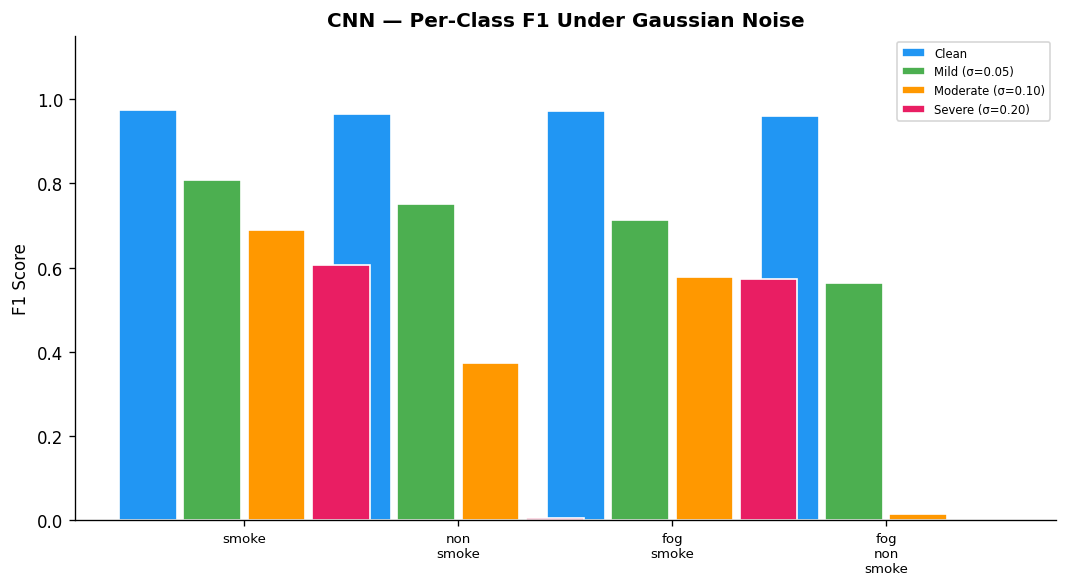

Saved: noise_f1_grouped.png


In [26]:
x       = np.arange(NUM_CLASSES)
width   = 0.15
offsets = [-3, -1, 1, 3]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (label, color) in enumerate(zip(
        ['Clean'] + list(NOISE_LEVELS.keys()),
        ['#2196F3', '#4CAF50', '#FF9800', '#E91E63'])):
    rep = results_noise['CNN'][label]['report']
    f1s = [rep[c]['f1-score'] for c in CLASS_NAMES]
    ax.bar(x + offsets[i] * width, f1s, width * 1.8,
           label=label, color=color, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in CLASS_NAMES], fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title('CNN — Per-Class F1 Under Gaussian Noise', fontweight='bold')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('noise_f1_grouped.png', bbox_inches='tight')
plt.show()
print('Saved: noise_f1_grouped.png')